In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('gym_members_exercise_tracking.csv')
df.head()  

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

In [3]:
df.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


In [4]:
df.isnull().sum()

Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

In [5]:
df['Gender_encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [6]:
df = pd.get_dummies(df, columns=['Workout_Type'])
#One-Hot Encoding

In [7]:
correlation = df.corr(numeric_only=True)
correlation

#print(correlation)   

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_encoded,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
Age,1.000000,-0.036340,-0.027837,-0.017073,0.035969,0.004354,-0.019912,-0.154679,0.002370,0.041528,0.008055,-0.018676,-0.013691,-0.027175,-0.049580,0.011677,0.013132,0.025819
Weight (kg),-0.036340,1.000000,0.365321,0.057061,0.009717,-0.032138,-0.013666,0.095443,-0.225512,0.394276,-0.011769,0.003379,0.853158,-0.579340,0.027736,0.019779,-0.047244,0.000860
Height (m),-0.027837,0.365321,1.000000,-0.017660,-0.014776,-0.005090,-0.010206,0.086348,-0.235521,0.393533,-0.011270,-0.010267,-0.159469,-0.583503,-0.014240,-0.013645,-0.027642,0.056175
Max_BPM,-0.017073,0.057061,-0.017660,1.000000,-0.039751,0.036647,0.010051,0.002090,-0.009056,0.031621,-0.029099,0.000545,0.067105,-0.010245,-0.000484,0.010789,-0.044674,0.035805
Avg_BPM,0.035969,0.009717,-0.014776,-0.039751,1.000000,0.059636,0.016014,0.339659,-0.007302,-0.002911,-0.010681,-0.000888,0.021605,-0.009648,0.005133,-0.009143,0.022928,-0.019856
Resting_BPM,0.004354,-0.032138,-0.005090,0.036647,0.059636,1.000000,-0.016649,0.016518,-0.016834,0.007726,-0.007967,0.001758,-0.032543,-0.014062,-0.019106,0.034404,0.019858,-0.034331
Session_Duration (hours),-0.019912,-0.013666,-0.010206,0.010051,0.016014,-0.016649,1.000000,0.908140,-0.581520,0.283411,0.644140,0.764768,-0.006493,0.012200,-0.063174,0.048439,0.006538,0.010688
Calories_Burned,-0.154679,0.095443,0.086348,0.002090,0.339659,0.016518,0.908140,1.000000,-0.597615,0.356931,0.576150,0.694129,0.059761,-0.150646,-0.045726,0.040550,0.011629,-0.004678
Fat_Percentage,0.002370,-0.225512,-0.235521,-0.009056,-0.007302,-0.016834,-0.581520,-0.597615,1.000000,-0.588683,-0.537060,-0.654363,-0.119258,0.407309,0.040091,-0.044685,0.046331,-0.044975
Water_Intake (liters),0.041528,0.394276,0.393533,0.031621,-0.002911,0.007726,0.283411,0.356931,-0.588683,1.000000,0.238563,0.304104,0.213697,-0.667658,-0.009692,0.023788,-0.027432,0.014878


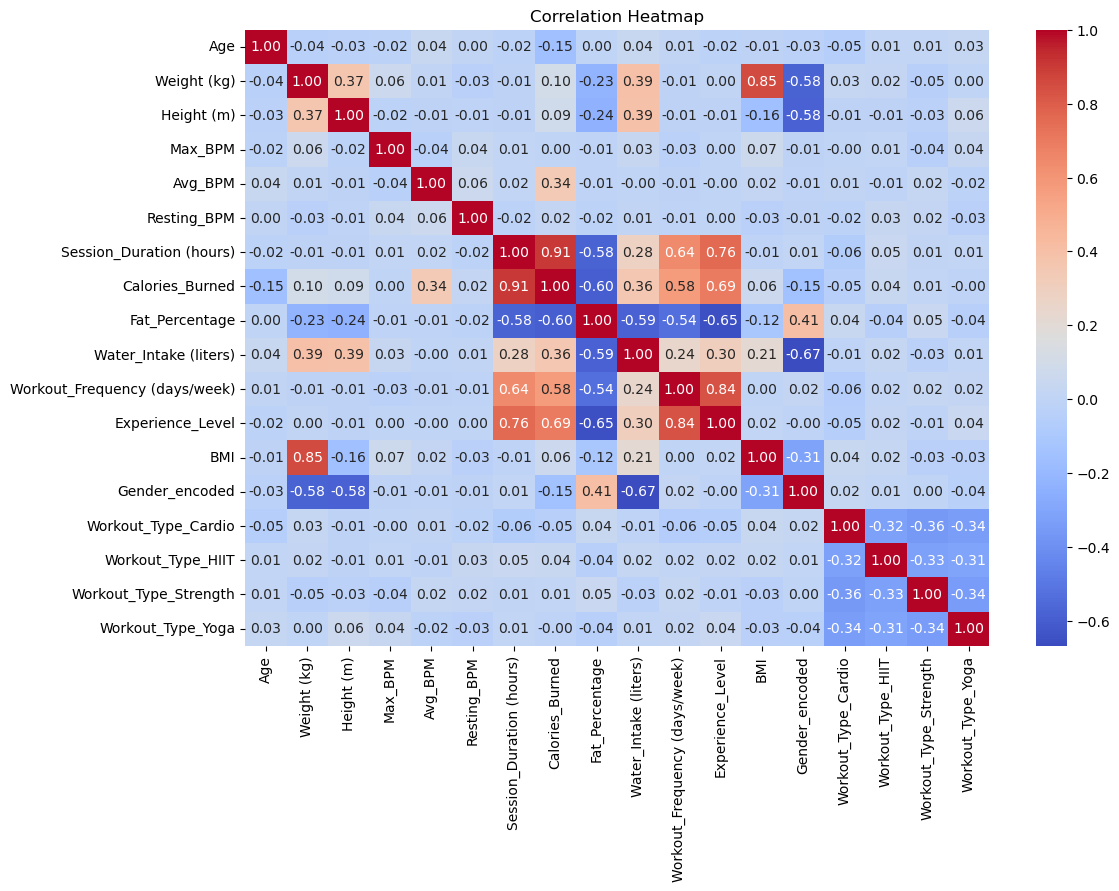

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [9]:
correlation = df.corr(numeric_only=True)
correlation["Calories_Burned"].sort_values(ascending=False)

Calories_Burned                  1.000000
Session_Duration (hours)         0.908140
Experience_Level                 0.694129
Workout_Frequency (days/week)    0.576150
Water_Intake (liters)            0.356931
Avg_BPM                          0.339659
Weight (kg)                      0.095443
Height (m)                       0.086348
BMI                              0.059761
Workout_Type_HIIT                0.040550
Resting_BPM                      0.016518
Workout_Type_Strength            0.011629
Max_BPM                          0.002090
Workout_Type_Yoga               -0.004678
Workout_Type_Cardio             -0.045726
Gender_encoded                  -0.150646
Age                             -0.154679
Fat_Percentage                  -0.597615
Name: Calories_Burned, dtype: float64

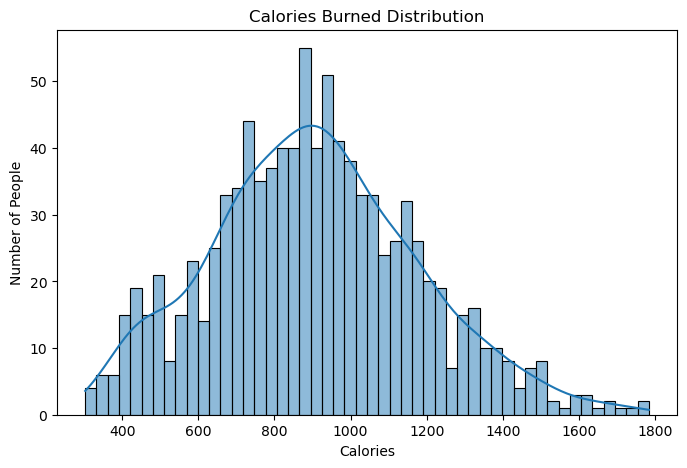

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Calories_Burned"],
    bins=50,
    kde=True
)

plt.title("Calories Burned Distribution")
plt.xlabel("Calories")
plt.ylabel("Number of People")

plt.show()

In [11]:
df[df["Calories_Burned"] > 1500]

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_encoded,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
66,32,Male,85.9,1.60,176,145,60,1.99,1587.0,14.5,3.5,5,3,33.55,0,False,True,False,False
90,25,Male,81.5,1.61,170,159,63,1.93,1688.0,10.9,3.5,4,3,31.44,0,False,True,False,False
99,24,Female,60.1,1.79,170,165,63,1.97,1625.0,15.9,2.7,4,3,18.76,1,True,False,False,False
124,26,Male,86.2,1.68,189,157,72,1.97,1701.0,13.3,3.5,5,3,30.54,0,False,False,True,False
132,49,Male,82.8,1.95,183,159,73,1.91,1503.0,14.3,3.5,5,3,21.78,0,False,False,False,True
391,43,Male,82.9,1.95,181,160,70,1.90,1505.0,12.9,3.5,5,3,21.80,0,True,False,False,False
475,27,Male,89.3,1.64,192,162,64,1.82,1622.0,12.1,3.5,4,3,33.20,0,False,True,False,False
511,39,Male,86.2,1.82,191,160,72,1.96,1725.0,10.2,3.5,5,3,26.02,0,False,False,True,False
572,36,Male,88.0,1.71,185,160,73,1.87,1646.0,12.0,3.5,5,3,30.09,0,False,True,False,False
587,18,Male,83.2,1.96,183,150,67,1.83,1510.0,13.6,3.5,4,3,21.66,0,False,True,False,False


In [12]:
features = ['Session_Duration (hours)', 'Experience_Level', 'Fat_Percentage', 
            'Workout_Frequency (days/week)', 'Water_Intake (liters)', 'Avg_BPM']

X = df[features]
y = df['Calories_Burned']

print(X.shape)
print(y.shape)

(973, 6)
(973,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(778, 6)
(195, 6)


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train , y_train)
y_pred = model.predict(X_test)

print(model.coef_)
print(model.intercept_)

[688.82999178  -9.48130872  -2.96641885  -2.76670701  37.54550836
   5.95276492]
-813.943377171435


In [15]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R²: 0.9451321394878496
MAE: 53.44934785369064
RMSE: 67.65613549482681


In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("R² (Random Forest):", r2_rf)
print("MAE (Random Forest):", mae_rf)
print("RMSE (Random Forest):", rmse_rf)

R² (Random Forest): 0.9496582640762041
MAE (Random Forest): 52.8214358974359
RMSE (Random Forest): 64.80556002579108


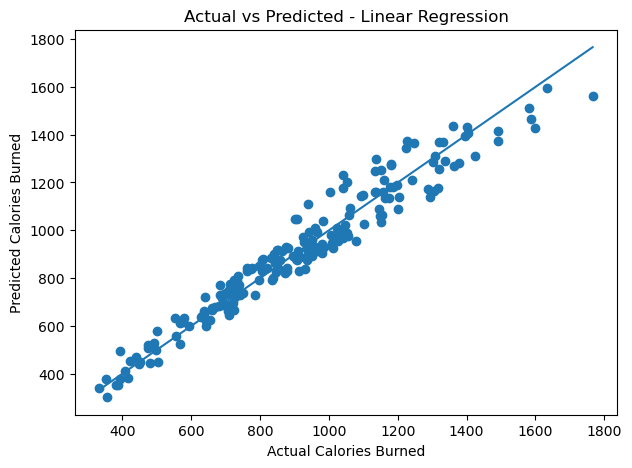

In [17]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title("Actual vs Predicted - Linear Regression")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

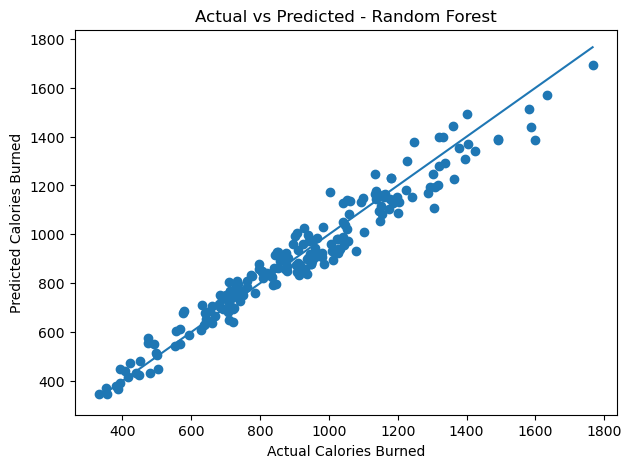

In [18]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title("Actual vs Predicted - Random Forest")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [19]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                         Feature  Importance
0       Session_Duration (hours)    0.842045
5                        Avg_BPM    0.110489
2                 Fat_Percentage    0.029951
4          Water_Intake (liters)    0.013942
3  Workout_Frequency (days/week)    0.002776
1               Experience_Level    0.000796


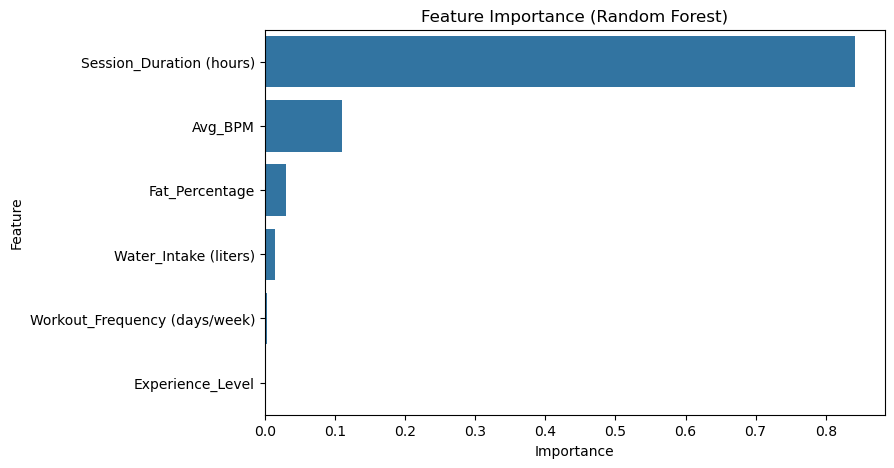

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [21]:
results = {
    "Model": ["Linear Regression", "Random Forest"],
    "R2": [r2, r2_rf],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf]
}

results_df = pd.DataFrame(results)

print(results_df)


               Model        R2        MAE       RMSE
0  Linear Regression  0.945132  53.449348  67.656135
1      Random Forest  0.949658  52.821436  64.805560


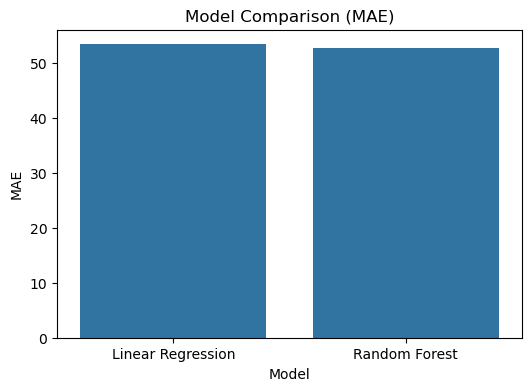

In [22]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=results_df,
    x="Model",
    y="MAE"
)

plt.title("Model Comparison (MAE)")

plt.show()

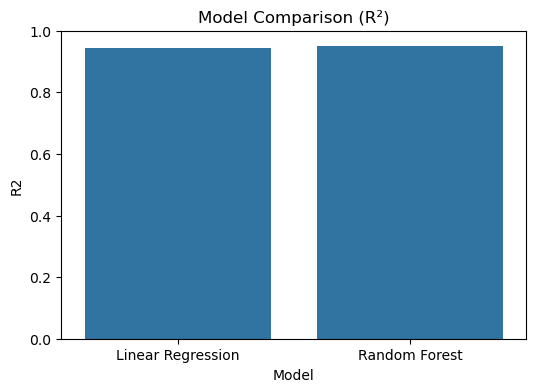

In [23]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2"
)

plt.title("Model Comparison (R²)")
plt.ylim(0, 1)

plt.show()

In [58]:
import joblib

joblib.dump(model, 'linear_regression_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')

print("saved!")

saved!


In [66]:
loaded_lr = joblib.load('linear_regression_model.pkl')
loaded_rf = joblib.load('random_forest_model.pkl')

print("LR prediction:", loaded_lr.predict(X_test[:3]))
print("RF prediction:", loaded_rf.predict(X_test[:3]))
print("Actual values:", y_test[:3].values)
print(y_test[:3].index.tolist())

LR prediction: [ 837.28431288 1432.06731203  971.12514535]
RF prediction: [ 858.55 1491.51  959.6 ]
Actual values: [ 929. 1401.  925.]
[199, 538, 174]


In [25]:
# Conclusion

# Hi🦥
# In this project, machine learning models were used to predict calories burned during exercise.

# Two regression models were trained and evaluated:
# - Linear Regression
# - Random Forest Regressor

# Linear Regression:
# R² = 0.945⭐️
# MAE = 53.4
# RMSE = 67.6

# Random Forest:
# R² = 0.949
# MAE = 52
# RMSE = 64

# The performance of both models was compared using three evaluation metrics:
# R² score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).

# The results showed that both models performed very well. 
# Linear Regression achieved an R² score of approximately 0.945, while Random Forest achieved an R² score of approximately 0.949.

# Although Random Forest performed slightly better, the difference between the two models was very small. Therefore, considering the simplicity, faster training time, and lower computational cost of Linear Regression, it can be a practical choice for this problem.

# Overall, both models were able to predict calories burned during exercise with high accuracy.
#thank you❤️🦋